# Motivation
I'm preparing my room for a acoustic treatment and I want learn the core room acoustic treatement and how it is going to affect hte frequency response across a room. In the process, I want to learn about the current best practices and what gaps in products exists in terms of tools and products or equipments.

Ref: https://python-sounddevice.readthedocs.io/en/0.5.3/usage.html

The first step is to get familiar with Python `sounddevice` library. I would be just recording audio just from the laptop and playing it back.

In [1]:
import sounddevice as sd
from scipy.io.wavfile import write
from IPython.display import Audio, Image
import numpy as np
from audio_utils import plot_signal

# Configuration parameters
fs = 44100       # Sample rate (CD quality)
seconds = 5      # Duration of recording
filename = '../resources/output.wav'
filename2 = '../resources/output-playback.wav'
sd.default.samplerate = fs
sd.default.channels = 2

In [2]:
duration = 10.5  # seconds
myrecording = sd.rec(int(duration * fs), samplerate=fs, channels=1)
sd.wait()        # Wait until the recording finishes
print("Recording finished. Saving file...")

# Save the recording as a WAV file
write(filename, fs, myrecording)
print(f"Saved as {filename}")

Recording finished. Saving file...
Saved as ../resources/output.wav


In [3]:
Audio(filename, rate=fs)  # Play back the recording

(<Figure size 1000x700 with 2 Axes>,
 (<Axes: title={'center': 'Waveform'}, xlabel='Time (s)', ylabel='Amplitude'>,
  <Axes: title={'center': 'Mean mel spectrum'}, xlabel='Frequency (Hz)', ylabel='Power (dB)'>))

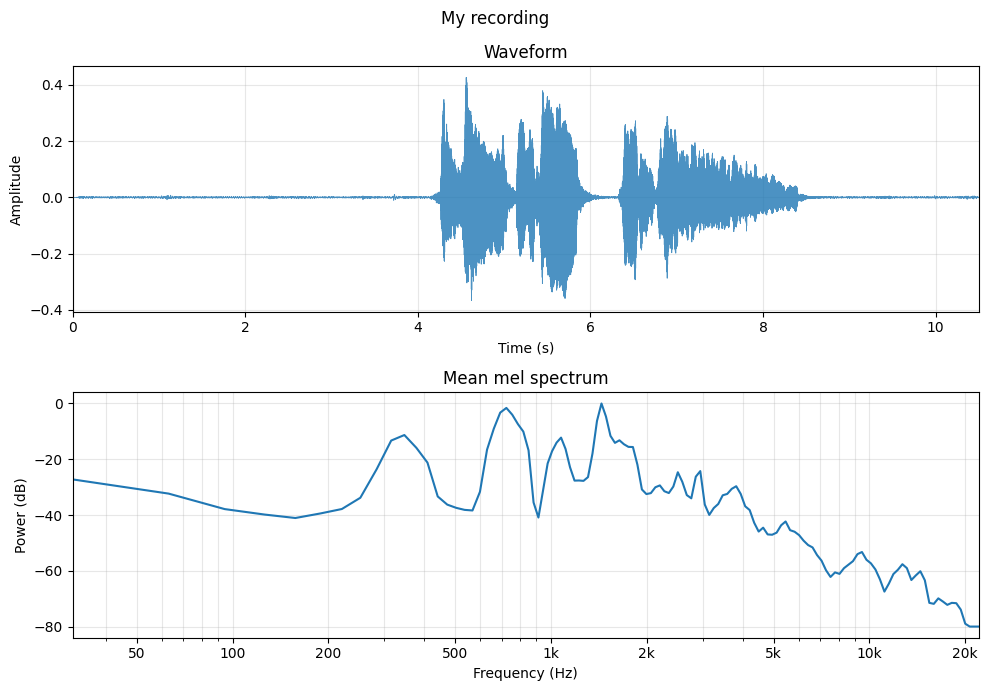

In [4]:
plot_signal(myrecording, fs, title='My recording')

The second step is to use `playrec` function which record the play simultaneuosly

In [5]:
duration = 2.0      # seconds
freq = 440.0        # Hz (A4)

t = np.linspace(0, duration, int(fs * duration), endpoint=False)
sine = (0.5 * np.sin(2 * np.pi * freq * t)).astype(np.float32)   # 0.5 = headroom, avoids clipping

# pad with silence so the recording catches the tail after playback latency
sine = np.concatenate([sine, np.zeros(int(0.5 * fs), dtype=np.float32)])

myrecording2 = sd.playrec(sine, fs, channels=1, dtype='float32')
sd.wait()

write(filename2, fs, myrecording2)
# or 16-bit PCM, which plays everywhere:
# write(filename2, fs, (np.clip(myrecording2, -1, 1) * 32767).astype(np.int16))

In [6]:
Audio(filename2, rate=fs)  # Play back the recording

(<Figure size 1000x700 with 2 Axes>,
 (<Axes: title={'center': 'Waveform'}, xlabel='Time (s)', ylabel='Amplitude'>,
  <Axes: title={'center': 'Mean mel spectrum'}, xlabel='Frequency (Hz)', ylabel='Power (dB)'>))

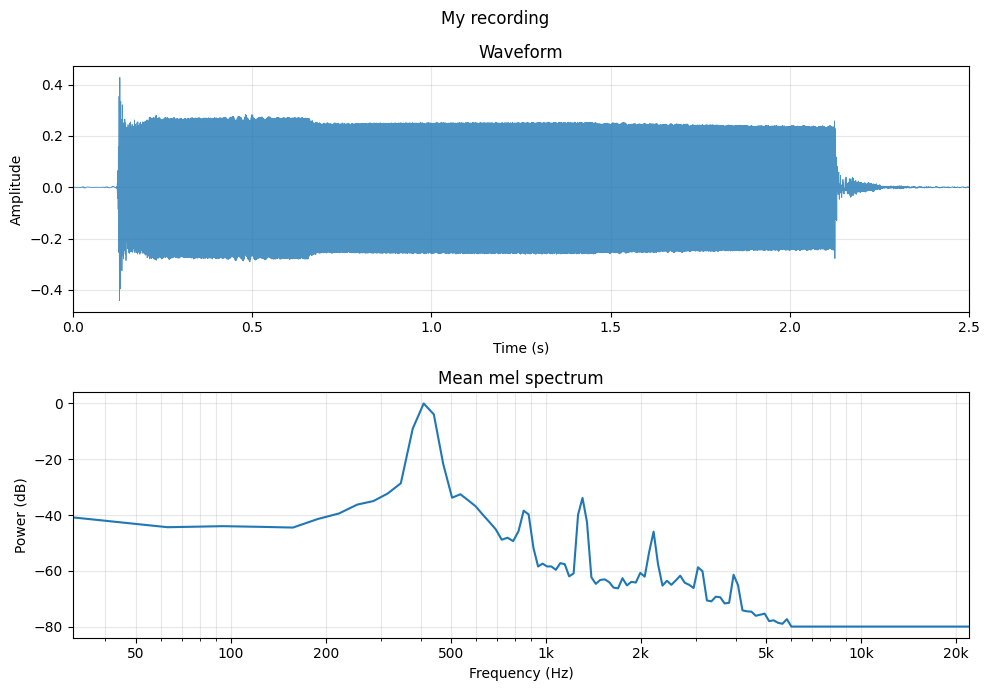

In [7]:
plot_signal(myrecording2, fs, title='My recording')

(<Figure size 1000x700 with 2 Axes>,
 (<Axes: title={'center': 'Waveform'}, xlabel='Time (s)', ylabel='Amplitude'>,
  <Axes: title={'center': 'Mean mel spectrum'}, xlabel='Frequency (Hz)', ylabel='Power (dB)'>))

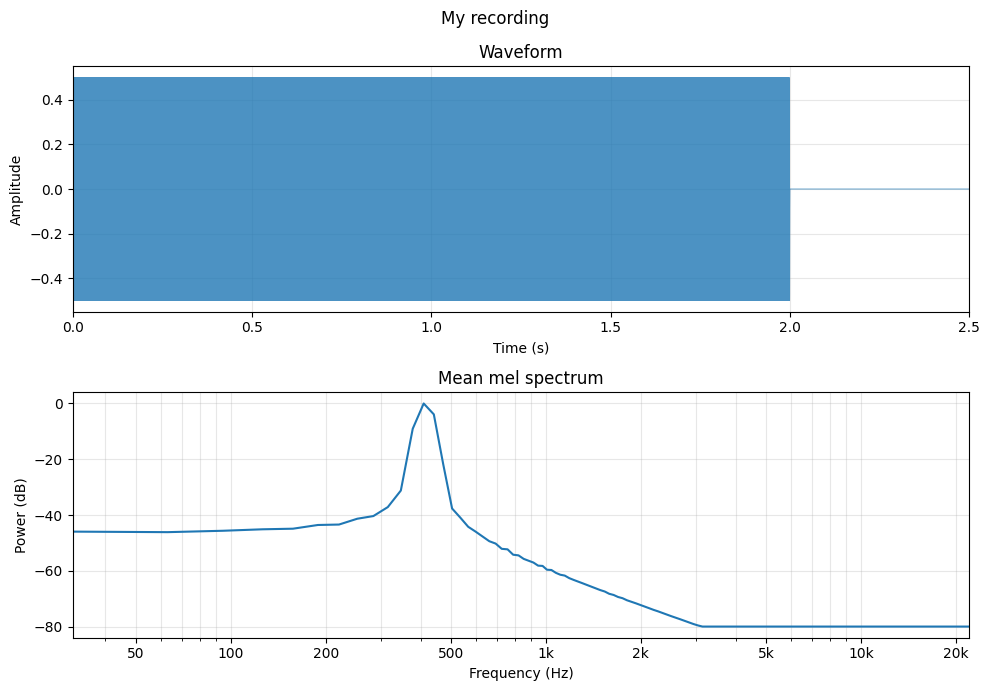

In [8]:
plot_signal(sine, fs, title='My recording')

Third step would be to manage recording devices

Fourth step would be to add a click sound and check with overlapping signals on for any delayes in signal phase